In [68]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from glob import glob

import tensorflow as tf

from PIL import Image
import cv2

from sklearn import preprocessing
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

import xgboost
import warnings
warnings.filterwarnings("ignore")

In [69]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/sartajbhuvaji
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training/no_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training/pituitary_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training/meningioma_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training/glioma_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing/no_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing/pituitary_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing/meningioma_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Test

In [70]:
base_dir = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri"

glioma = glob(base_dir + "/Training/glioma_tumor/*")
meningioma = glob(base_dir + "/Training/meningioma_tumor/*")
no_tumor = glob(base_dir + "/Training/no_tumor/*")
pituitary = glob(base_dir + "/Training/pituitary_tumor/*")

print("Glioma Images:", len(glioma))
print("Meningioma Images:", len(meningioma))
print("No Tumor Images:", len(no_tumor))
print("Pituitary Images:", len(pituitary))
print("\nTotal Images:",len(glioma + meningioma + no_tumor + pituitary))

Glioma Images: 826
Meningioma Images: 822
No Tumor Images: 395
Pituitary Images: 827

Total Images: 2870


In [71]:
import random

#80 train 5% validate 15% test
# Glioma
glioma_train = glioma[:660]
glioma_test  = glioma[660:784]
glioma_val   = glioma[784:826]

# Meningioma
meningioma_train = meningioma[:657]
meningioma_test  = meningioma[657:781]
meningioma_val   = meningioma[781:822]

# No Tumor
no_train = no_tumor[:316]
no_test  = no_tumor[316:375]
no_val   = no_tumor[375:395]

# Pituitary
pituitary_train = pituitary[:661]
pituitary_test  = pituitary[661:785]
pituitary_val   = pituitary[785:827]

train_imgs = ( glioma_train + meningioma_train + no_train + pituitary_train)
test_imgs = ( glioma_test + meningioma_test +no_test + pituitary_test)
val_imgs = (glioma_val +meningioma_val +no_val +pituitary_val)

print("Total Train Images %s containing %s glioma, %s meningioma, %s no_tumor and %s pituitary images"
    % (len(train_imgs),len(glioma_train),len(meningioma_train),len(no_train),len(pituitary_train)))

print("Total Test Images %s containing %s glioma, %s meningioma, %s no_tumor and %s pituitary images"
    % ( len(test_imgs), len(glioma_test), len(meningioma_test), len(no_test), len(pituitary_test)))

print("Total Validation Images %s containing %s glioma, %s meningioma, %s no_tumor and %s pituitary images"
    % (len(val_imgs),len(glioma_val),len(meningioma_val),len(no_val),len(pituitary_val)))

random.seed(42)
random.shuffle(glioma)
random.shuffle(meningioma)
random.shuffle(no_tumor)
random.shuffle(pituitary)

Total Train Images 2294 containing 660 glioma, 657 meningioma, 316 no_tumor and 661 pituitary images
Total Test Images 431 containing 124 glioma, 124 meningioma, 59 no_tumor and 124 pituitary images
Total Validation Images 145 containing 42 glioma, 41 meningioma, 20 no_tumor and 42 pituitary images


In [72]:
def preprocess_image(image_list):
    X = []
    y = []

    for image in image_list:

        try:
            img = cv2.imread(image)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224,224))
            X.append(img)

        except:
            continue

        if 'glioma_tumor' in image:
            y.append(0)
        elif 'meningioma_tumor' in image:
            y.append(1)
        elif 'no_tumor' in image:
            y.append(2)
        elif 'pituitary_tumor' in image:
            y.append(3)

    return np.array(X), np.array(y)

In [73]:
X_train, y_train = preprocess_image(train_imgs)
X_test, y_test = preprocess_image(test_imgs)
X_val, y_val = preprocess_image(val_imgs)

print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(2294, 224, 224, 3)
(431, 224, 224, 3)
(145, 224, 224, 3)


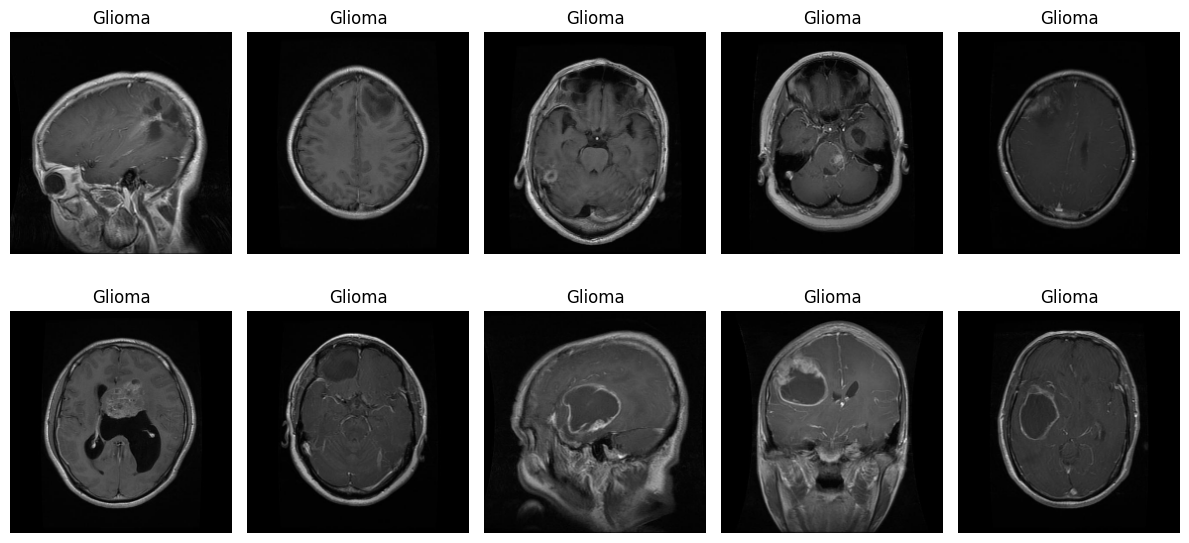

In [74]:
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [75]:
from tensorflow.keras.applications import VGG16

IMG_SIZE = (224, 224)

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [76]:
base_model.trainable = False
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [77]:
print("Extracting training features...")
X_train_features = base_model.predict(X_train, verbose=1)

X_train_features = X_train_features.reshape(
    X_train_features.shape[0], -1
)

del X_train

print("Extracting validation features...")
X_val_features = base_model.predict(X_val, verbose=1)

X_val_features = X_val_features.reshape(
    X_val_features.shape[0], -1
)

del X_val

print("Extracting test features...")
X_test_features = base_model.predict(X_test, verbose=1)

X_test_features = X_test_features.reshape(
    X_test_features.shape[0], -1
)

del X_test

Extracting training features...
72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step
Extracting validation features...
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step
Extracting test features...
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step


In [78]:
from xgboost import XGBClassifier

xgb_params = {
    'objective': 'multi:softmax',
    'num_class': 4,
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 200,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'eval_metric': ['merror', 'mlogloss'],
    'verbosity': 1
}

xgb_model = XGBClassifier(**xgb_params)

In [79]:
xgb_model.fit(
    X_train_features,
    y_train,
    eval_set=[
        (X_train_features, y_train),
        (X_val_features, y_val)
    ],
    verbose=True
)

[0]	validation_0-merror:0.22624	validation_0-mlogloss:1.21649	validation_1-merror:0.36552	validation_1-mlogloss:1.24664
[1]	validation_0-merror:0.18439	validation_0-mlogloss:1.10159	validation_1-merror:0.31724	validation_1-mlogloss:1.16178
[2]	validation_0-merror:0.09241	validation_0-mlogloss:1.00589	validation_1-merror:0.28966	validation_1-mlogloss:1.09277
[3]	validation_0-merror:0.05972	validation_0-mlogloss:0.91919	validation_1-merror:0.25517	validation_1-mlogloss:1.02487
[4]	validation_0-merror:0.04185	validation_0-mlogloss:0.84304	validation_1-merror:0.21379	validation_1-mlogloss:0.97092
[5]	validation_0-merror:0.03487	validation_0-mlogloss:0.77617	validation_1-merror:0.17241	validation_1-mlogloss:0.91788
[6]	validation_0-merror:0.02746	validation_0-mlogloss:0.71644	validation_1-merror:0.18621	validation_1-mlogloss:0.87415
[7]	validation_0-merror:0.02485	validation_0-mlogloss:0.66118	validation_1-merror:0.18621	validation_1-mlogloss:0.82695
[8]	validation_0-merror:0.02092	validati

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=['merror', 'mlogloss'],
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None, num_class=4, ...)

In [80]:
print(X_train_features.shape)
print(X_val_features.shape)
print(X_test_features.shape)

(2294, 25088)
(145, 25088)
(431, 25088)


In [81]:
results = xgb_model.evals_result()

train_error = results['validation_0']['merror']
train_acc = [1.0 - i for i in train_error]

val_error = results['validation_1']['merror']
val_acc = [1.0 - i for i in val_error]

train_logloss = results['validation_0']['mlogloss']
val_logloss = results['validation_1']['mlogloss']

import numpy as np

best_round = np.argmin(val_logloss)

print("Best Boosting Round :", best_round + 1)
print("Lowest Validation Log Loss :", min(val_logloss))

Best Boosting Round : 198
Lowest Validation Log Loss : 0.21112031755378824


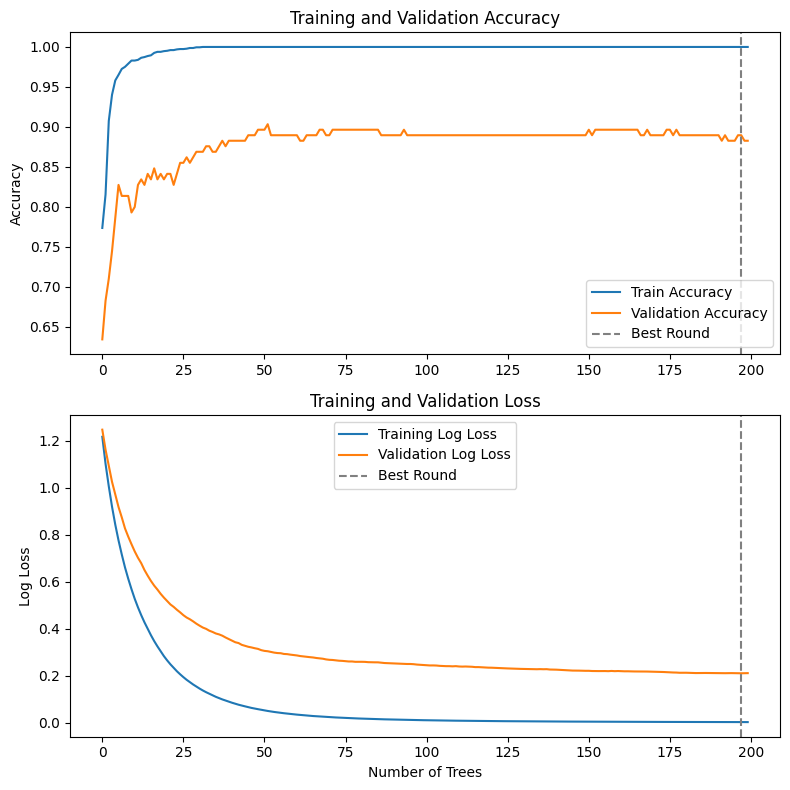

In [82]:
plt.figure(figsize=(8,8))

plt.subplot(2,1,1)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(best_round, color='gray', linestyle='--',
            label='Best Round')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2,1,2)
plt.plot(train_logloss, label='Training Log Loss')
plt.plot(val_logloss, label='Validation Log Loss')
plt.axvline(best_round, color='gray', linestyle='--',
            label='Best Round')
plt.ylabel('Log Loss')
plt.xlabel('Number of Trees')
plt.legend()
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()

In [83]:
train_predictions = xgb_model.predict(X_train_features)
val_predictions = xgb_model.predict(X_val_features)
test_predictions = xgb_model.predict(X_test_features)

print("Training Accuracy = ",accuracy_score(y_train, train_predictions))
print("Test Accuracy = ",accuracy_score(y_test, test_predictions))
print("Validation Accuracy = ",accuracy_score(y_val, val_predictions))

Training Accuracy =  1.0
Test Accuracy =  0.9327146171693735
Validation Accuracy =  0.8827586206896552


In [84]:
predictions = xgb_model.predict(X_test_features)

print("Evaluating the Algorithm\n")

print("Accuracy :", accuracy_score(y_test, predictions))
print("Precision:", precision_score(y_test, predictions, average='weighted'))
print("Recall   :", recall_score(y_test, predictions, average='weighted'))
print("F1 Score :", f1_score(y_test, predictions, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, predictions))

Evaluating the Algorithm

Accuracy : 0.9327146171693735
Precision: 0.9323049734792431
Recall   : 0.9327146171693735
F1 Score : 0.9323964140635943

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.94      0.93       124
           1       0.91      0.88      0.89       124
           2       0.93      0.93      0.93        59
           3       0.96      0.98      0.97       124

    accuracy                           0.93       431
   macro avg       0.93      0.93      0.93       431
weighted avg       0.93      0.93      0.93       431



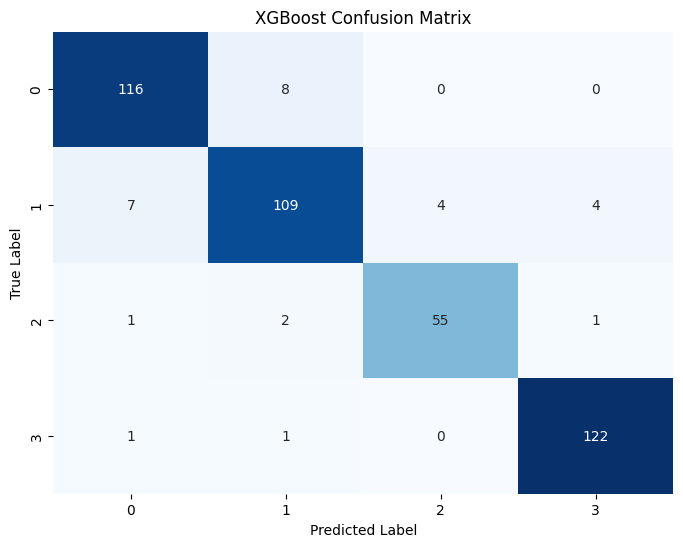

In [87]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred = xgb_model.predict(X_test_features)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("XGBoost Confusion Matrix")

plt.show()